# Modelling

In [74]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from logitplots import plt_confusion_matrix, plt_decision_boundaries, plt_correlation_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# import data
data = pd.read_csv("/Users/jiehni/monash/ADS2001_GROUPMC3/data/processed/melb.csv")
data.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,11,...,False,False,False,True,False,False,False,False,False,False
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,11,...,False,False,False,True,False,False,False,False,False,False
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,9,...,False,False,False,False,False,False,False,False,False,False


### Decision Tree for Level of Rain

Decision Tree Level of Rain (no rain: 0mm, light rain: 0-2mm, moderate rain: 2-10mm, heavy rain: 10-50mm, extreme rain: 50+mm) – Jiehni

In [102]:
# create bins for rain level
data["Rainfall Band"] = pd.cut(
    data["Rainfall since 9 am (mm)"],
    bins=[-0.1, 0, 2, 10, 50, np.inf],
    labels=["No Rain", "Light", "Medium", "Heavy", "Extreme"]
)

# select variables
X = data.drop(["Rainfall since 9 am (mm)", "Rainfall Band", "Rain", "Datetime"], axis=1)
y = data["Rainfall Band"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [103]:
print(data["Rainfall Band"].value_counts())

Rainfall Band
No Rain    245274
Light       51625
Medium      25153
Heavy        7591
Extreme         4
Name: count, dtype: int64


In [104]:
param_grid = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf': [5, 10, 20, 50]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',  # use 'f1' if binary
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'max_depth': 25, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best score: 0.8859535479334453


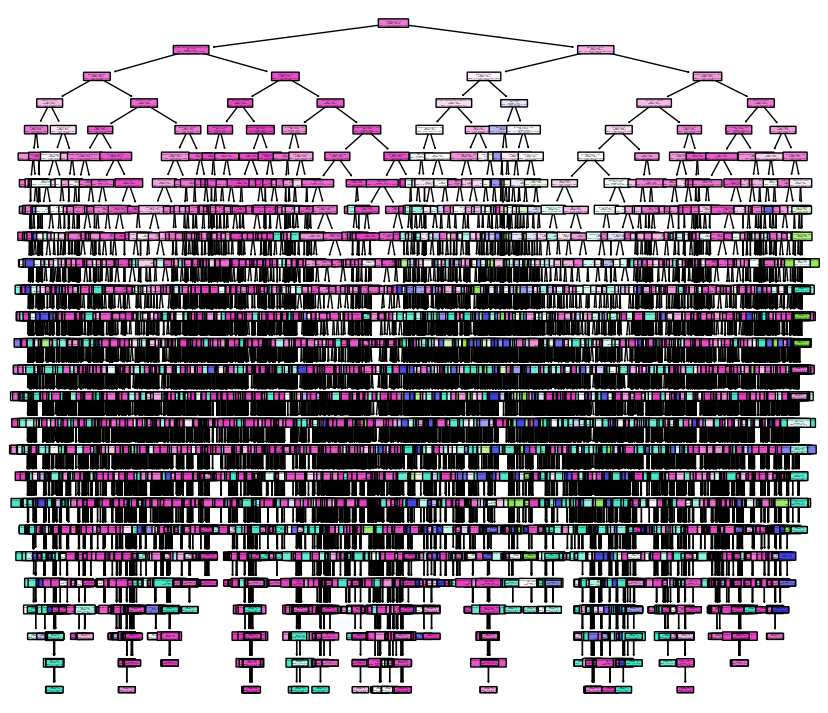

In [105]:
data_dtc = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=25) 

data_dtc = data_dtc.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc,
    filled=True,
    rounded=True,
    class_names=data_dtc.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

In [107]:
# feature importance
importance = pd.Series(data_dtc.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Day                                     0.155059
MSLP (hPa)                              0.148723
Humidity (%)                            0.144126
Year                                    0.091062
Month                                   0.088839
Hour                                    0.078239
Apparent Temp (degrees C)               0.052298
Calculated Apparent Temp (degrees C)    0.048605
Air Temp (degrees C)                    0.041240
Wind Gust  (km/h)                       0.028745
gamma                                   0.021833
E (hPa)                                 0.021302
WindDir_N                               0.017100
Dew Pt Temp (degrees C)                 0.013100
Wind Speed (km/h)                       0.010425
Calculated Dew Pt Temp (degrees C)      0.009911
WindDir_S                               0.003857
WindDir_SW                              0.003408
Minute                                  0.003270
WindDir_NNE                             0.003243
WindDir_WSW         

Most important features are Day, MSLP (hPa) and Humidity (%).

Decision Tree Accuracy: 0.901


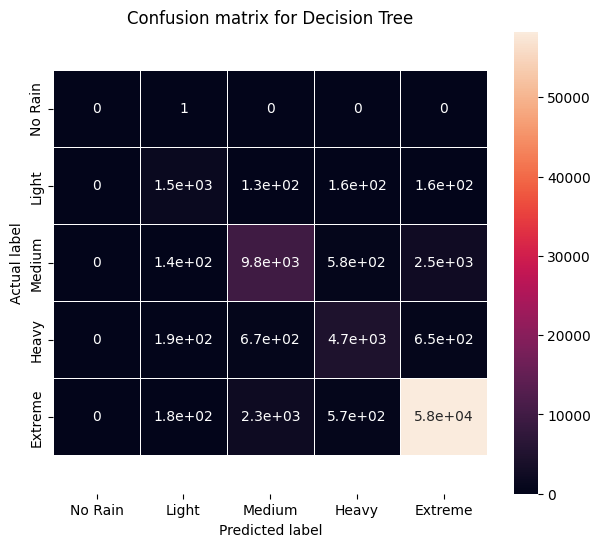

In [108]:
Y_pred = data_dtc.predict(X_test)
cm = confusion_matrix(y_test, Y_pred)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy", "Extreme"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred),3))

In [111]:
data_dtc.fit(X_train, y_train)

train_score = data_dtc.score(X_train, y_train)
test_score = data_dtc.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.9515036301494529
Test score: 0.9011430374217347


In [112]:
print(classification_report(y_test, Y_pred))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     Extreme       0.00      0.00      0.00         1
       Heavy       0.74      0.77      0.75      1920
       Light       0.76      0.76      0.76     12957
      Medium       0.78      0.76      0.77      6257
     No Rain       0.95      0.95      0.95     61277

    accuracy                           0.90     82412
   macro avg       0.65      0.65      0.65     82412
weighted avg       0.90      0.90      0.90     82412



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The dataset has severe class imbalance with majority of observations belonging to the "No Rain" class and only 1 "Extreme" rainfall event. As a result, the decision tree model is highly biased to the majority classes as shown by the low recall and f1 scores.

Hence, accuracy alone is not a reliable metric and the class imbalance must be addressed to improve the model's performance. To combat this we will reduce the number of classes and remove "Extreme" class. 

In [113]:
# reduce number of classes
data["Rainfall Band"] = pd.cut(
    data["Rainfall since 9 am (mm)"],
    bins=[-0.1, 0, 5, 20, np.inf],
    labels=["No Rain", "Light", "Medium", "Heavy"]
)

# select variables
X = data.drop(["Rainfall since 9 am (mm)", "Rainfall Band", "Rain", "Datetime"], axis=1)
y = data["Rainfall Band"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [114]:
print(data["Rainfall Band"].value_counts())

Rainfall Band
No Rain    245274
Light       67670
Medium      14273
Heavy        2430
Name: count, dtype: int64


This distribution is more even compared to before

In [115]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',  # use 'f1' if binary
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'max_depth': 25, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best score: 0.8965063307203804


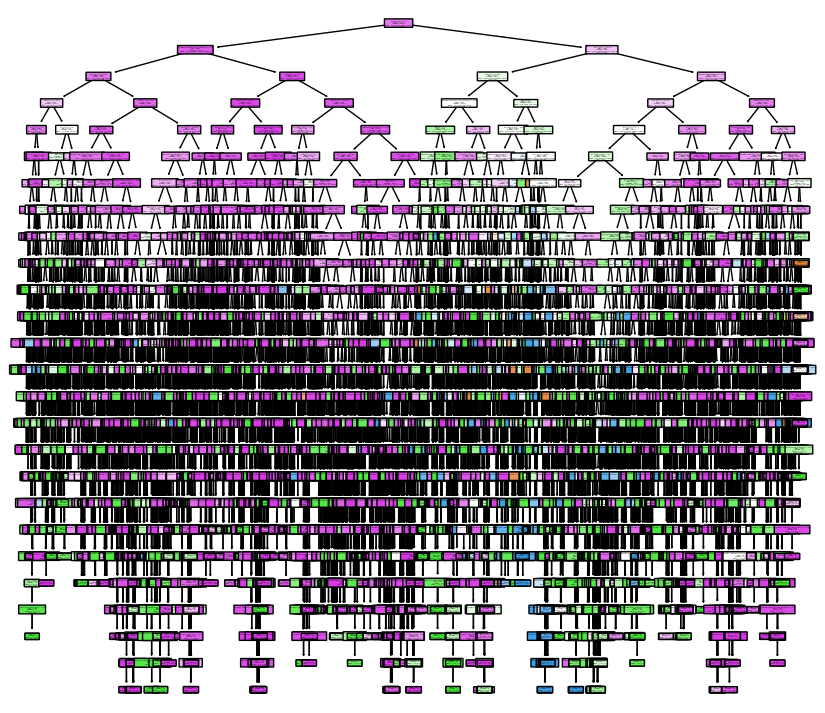

In [116]:
data_dtc2 = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=25) 

data_dtc2 = data_dtc2.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc2,
    filled=True,
    rounded=True,
    class_names=data_dtc2.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

Decision Tree Accuracy: 0.861


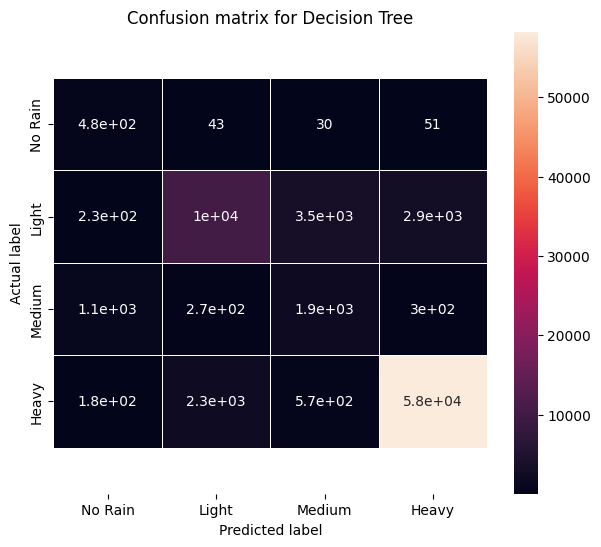

In [117]:
Y_pred = data_dtc.predict(X_test)
cm = confusion_matrix(y_test, Y_pred)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred),3))

In [118]:
data_dtc2.fit(X_train, y_train)

train_score = data_dtc2.score(X_train, y_train)
test_score = data_dtc2.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.9579994741844804
Test score: 0.9096369460758142


In [119]:
labels = ["No Rain", "Light", "Medium", "Heavy"]

print(classification_report(y_test, Y_pred, labels=labels))

              precision    recall  f1-score   support

     No Rain       0.95      0.95      0.95     61277
       Light       0.80      0.61      0.69     16944
      Medium       0.32      0.54      0.40      3582
       Heavy       0.25      0.80      0.37       609

    accuracy                           0.86     82412
   macro avg       0.58      0.72      0.60     82412
weighted avg       0.88      0.86      0.87     82412



The model’s accuracy decreased to 0.861 as it attempted to better predict minority classes. 

In [121]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'max_depth': 25, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV score: 0.8888620633867138


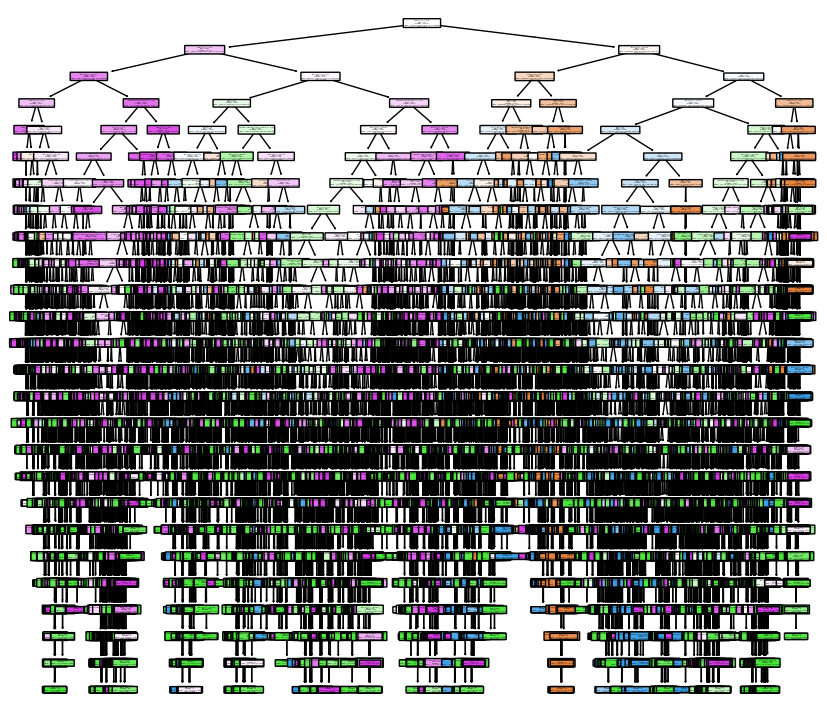

In [122]:
# balance classes
data_dtc_balanced = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=10,
    min_samples_leaf=5,
    max_depth=25,
    class_weight="balanced") 

data_dtc_balanced = data_dtc_balanced.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc_balanced,
    filled=True,
    rounded=True,
    class_names=data_dtc_balanced.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

Decision Tree Accuracy: 0.901


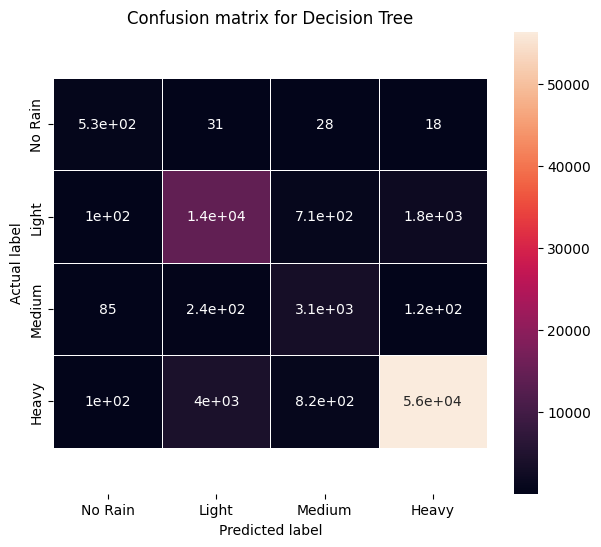

In [123]:
Y_pred_balanced = data_dtc_balanced.predict(X_test)
cm = confusion_matrix(y_test, Y_pred_balanced)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred_balanced),3))

In [126]:
data_dtc_balanced.fit(X_train, y_train)

train_score = data_dtc_balanced.score(X_train, y_train)
test_score = data_dtc_balanced.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.9480372924545473
Test score: 0.9013735863709168


In [124]:
labels = ["No Rain", "Light", "Medium", "Heavy"]

print(classification_report(y_test, Y_pred_balanced, labels=labels))

              precision    recall  f1-score   support

     No Rain       0.97      0.92      0.94     61277
       Light       0.77      0.84      0.80     16944
      Medium       0.67      0.88      0.76      3582
       Heavy       0.65      0.87      0.74       609

    accuracy                           0.90     82412
   macro avg       0.76      0.88      0.81     82412
weighted avg       0.91      0.90      0.90     82412



Applying class weighting improved the model’s ability to detect minority classes such as heavy rainfall but overall performance remained limited due to the severe class imbalance. 

The model’s accuracy increased again to 0.901 after class balancing. Performance improved drastically for "Heavy" and "Medium". Class weighting helped to reduce bias but it cannot fully compensate for insufficient data in rare categories.

In [130]:
y_shuffled = np.random.permutation(y)

scores = cross_val_score(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X,
    y_shuffled,
    cv=5,
    scoring="f1_weighted"
)

print(scores.mean())

0.3821277345977078


This checks whether the model is learning real patterns or just picking up unintended information from the data. By shuffling the labels, any true relationship between the features and the target is removed.

### Gradient Boosting

In [69]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_iter': [100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [None, 3, 5, 10],
    'min_samples_leaf': [20, 50, 100],
    'l2_regularization': [0.0, 0.1, 1.0]
}

rand = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        early_stopping=True,
        n_iter_no_change=10,
        validation_fraction=0.1,
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=30,             
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand.fit(X_train, y_train)

print("Best params:", rand.best_params_)
print("Best CV score:", rand.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'min_samples_leaf': 50, 'max_iter': 300, 'max_depth': None, 'learning_rate': 0.2, 'l2_regularization': 0.1}
Best CV score: 0.9587006625622575


In [70]:
gb_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.2,
    max_depth=None,
    min_samples_leaf=50,
    l2_regularization=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

Y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:",np.round(accuracy_score(y_test, Y_pred_gb),3))

Gradient Boosting Accuracy: 0.962


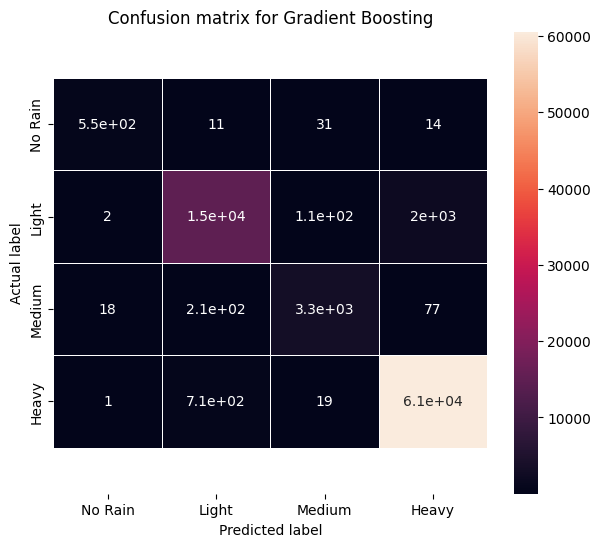

In [71]:
cm = confusion_matrix(y_test, Y_pred_gb)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy"], "Gradient Boosting") 

In [128]:
gb_model.fit(X_train, y_train)

train_score = gb_model.score(X_train, y_train)
test_score = gb_model.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.9793799421602929
Test score: 0.9617288744357618


In [72]:
labels = ["No Rain", "Light", "Medium", "Heavy"]

print(classification_report(y_test, Y_pred_gb, labels=labels))

              precision    recall  f1-score   support

     No Rain       0.97      0.99      0.98     61277
       Light       0.94      0.88      0.91     16944
      Medium       0.95      0.92      0.93      3582
       Heavy       0.96      0.91      0.93       609

    accuracy                           0.96     82412
   macro avg       0.96      0.92      0.94     82412
weighted avg       0.96      0.96      0.96     82412

